# Ensambles, validación cruzada anidada e interpretación (7.3 y 7.4)

En el notebook 04 reproducimos y adaptamos el SVM del artículo. Aquí completamos
el modelamiento de la Segunda entrega:

1. **Árboles, ensambles y selección de variables (7.3).** Entrenamos un árbol
   de decisión, Random Forest y Gradient Boosting con el mismo `Pipeline` sin
   fuga y la misma partición del notebook 03, cada uno con su espacio de
   hiperparámetros. Evaluamos además el SVM RBF con selección de variables por
   LASSO, una de las técnicas de selección que usa el artículo.
2. **Validación cruzada anidada (7.4).** Evaluamos *todos* los modelos (líneas
   base, SVM y ensambles) con el mismo esquema anidado. Reportamos F1, ROC-AUC y
   recall de la clase "malo" como media ± desviación entre folds. La accuracy va
   solo como referencia.
3. **Comparación.** Tabla de todos los modelos frente a las líneas base, prueba t
   corregida, evaluación en test y matrices de confusión.
4. **Análisis de errores del mejor modelo.** Vemos quiénes son los clientes mal
   clasificados y si esos errores se podían evitar.
5. **Primera lectura del mejor modelo.** Importancia por permutación, su
   estabilidad entre folds y su contraste con la estructura verdadera de la
   simulación, más lo que eso implica.

Todo el trabajo se hace con la **base simulada con faltantes**
(`credito_simulado_con_faltantes.csv`). El conjunto de test (1.300 clientes) no
se usa para elegir nada: solo se consulta al final para confirmar.

## 1. Diseño de la validación anidada

**Por qué anidada.** En el notebook 04 los hiperparámetros se eligieron con
validación cruzada, y el ROC-AUC de esa misma validación se reportó como
desempeño. Ese número es algo optimista: es el máximo de muchas combinaciones
evaluadas sobre los mismos folds, así que parte de la ventaja del ganador es
suerte. La validación anidada separa las dos tareas:

- **Ciclo externo (5 folds estratificados, semilla 42):** estima el desempeño.
  Son exactamente los mismos folds del notebook 04, así que los resultados se
  pueden comparar.
- **Ciclo interno (3 folds, solo con la parte de entrenamiento de cada fold
  externo):** elige los hiperparámetros por ROC-AUC y, con los mejores, el umbral
  de decisión que minimiza el costo 5:1. Luego se reajusta el modelo con todo el
  fold de entrenamiento y se evalúa **una sola vez** en el fold externo.

Así, cada número de la tabla viene de clientes que no participaron en ninguna
decisión del modelo: ni en la imputación ni en el escalamiento (que están en el
`Pipeline`), ni en los hiperparámetros, ni en el umbral. Usamos 3 folds internos
y no 5 para contener el costo computacional: el esquema completo ajusta más de
1.000 modelos. Toda la lógica está en `src/evaluacion.py`
(`ajustar_modelo` y `validacion_anidada`), para que el procedimiento evaluado sea
exactamente el mismo que luego se aplica a todo train.

**Métricas.**

- **ROC-AUC:** mide qué tan bien ordena el modelo a los clientes por riesgo, sin
  depender del umbral. Por eso es el criterio para elegir hiperparámetros.
- **Recall de "malo":** proporción de clientes riesgosos que el modelo detecta.
  Es la métrica que más directamente refleja un falso negativo 5 veces más caro.
- **F1 de "malo":** equilibra el recall con la precisión, para no premiar un
  modelo que rechace a casi todos.
- **Costo medio 5:1:** la matriz de costos del artículo, que es la que decide el
  umbral.
- **Accuracy:** solo como referencia. Con 22.5% de "malo", el clasificador de
  mayoría ya tiene 77.5% sin detectar a nadie.

F1, recall y costo se calculan con el umbral de costo mínimo, el mismo criterio
del notebook 04.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from sklearn.model_selection import StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score

sys.path.append("../src")
from preprocesamiento import SEED, CAT_COLS, cargar_particion, construir_pipeline
from evaluacion import (ajustar_modelo, validacion_anidada, metricas, p_valor_corregido,
                        costo_medio)
from generar_datos_simulados import generar_base, puntaje_latente

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.dpi"] = 110
DIR_RES = Path("../docs/resultados")
DIR_RES.mkdir(parents=True, exist_ok=True)

X_train, X_test, y_train_txt, y_test_txt = cargar_particion()
y_train = (y_train_txt == "malo").astype(int).to_numpy()   # 1 = malo
y_test = (y_test_txt == "malo").astype(int).to_numpy()

cv_externa = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)  # los mismos folds del notebook 04
cv_interna = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

# Probabilidad teórica P(malo | x) de la estructura generadora (índices de la partición = id - 1)
base_sin_faltantes, p_teorica = generar_base(seed=SEED, devolver_probabilidad=True)

print("Train:", X_train.shape, "| Test:", X_test.shape,
      "| % malo train/test:", round(y_train.mean(), 4), round(y_test.mean(), 4))

Train: (5200, 11) | Test: (1300, 11) | % malo train/test: 0.2246 0.2246


## 2. Modelos y espacios de hiperparámetros

Todos los modelos usan `construir_pipeline` de `src/preprocesamiento.py`. Así la
imputación, el escalamiento y el one-hot son idénticos y se ajustan dentro de
cada fold. El desbalance se trata con pesos de clase (`class_weight`), la
estrategia que ganó en el notebook 03. Para los árboles el escalamiento es
irrelevante (sus cortes no cambian con transformaciones monótonas), pero lo
mantenemos para que la comparación sea en igualdad de condiciones.

**Árbol de decisión.** Es el modelo de árboles más simple y uno de los modelos
tradicionales con los que el artículo compara el SVM. Divide a los clientes con
cortes sucesivos sobre una variable a la vez. Ajustamos la profundidad máxima,
el tamaño mínimo de las hojas (que limitan cuánto puede memorizar) y el
criterio de división (Gini o entropía).

**Random Forest.** Promedia muchos árboles profundos entrenados sobre muestras
bootstrap y con subconjuntos aleatorios de variables en cada corte, lo que
reduce la varianza de un árbol individual. Ajustamos:

- `max_depth` y `min_samples_leaf`: controlan cuánto puede memorizar cada árbol.
- `max_features`: cuántas columnas se consideran en cada corte. Menos columnas
  dan árboles más distintos entre sí.
- `class_weight`: `balanced` usa los pesos de todo el train; `balanced_subsample`
  los recalcula en cada muestra bootstrap.

Fijamos 300 árboles: más árboles no sobreajustan, solo estabilizan el promedio.

**Gradient Boosting.** Construye árboles pequeños en secuencia, cada uno
corrigiendo los errores de los anteriores. Usamos `HistGradientBoostingClassifier`
de scikit-learn. Es la misma familia de algoritmos que LightGBM (discretiza las
variables en histogramas y hace crecer cada árbol hoja por hoja), admite
`class_weight` y no agrega dependencias al proyecto. Ajustamos:

- `learning_rate` y `max_iter`: cuánto aporta cada árbol y cuántos árboles hay.
  Se compensan entre sí.
- `max_leaf_nodes`: la complejidad de cada árbol. Con 2 hojas (un solo corte, un
  *stump*) el modelo es **aditivo**: suma efectos de una variable a la vez, sin
  interacciones.
- `min_samples_leaf` y `l2_regularization`: regularización.

Incluimos los *stumps* a propósito. En un piloto con una malla que empezaba en 4
hojas, el modelo elegía siempre el extremo más simple, señal de que la malla
estaba mal ubicada.

**SVM y líneas base.** Mantenemos las líneas base del notebook 03 (mayoría y
regresión logística con `class_weight`) y los dos SVM del notebook 04. La malla
del SVM RBF es la de 5 × 5 alrededor de la meseta del notebook 04, recorrida con
búsqueda aleatoria (12 de 25 combinaciones), porque es el modelo más lento de
ajustar.

**SVM RBF con selección LASSO.** El artículo combina el SVM con selección de
variables (correlación, chi-cuadrado, RFE y LASSO). Para reproducir esa parte,
añadimos al `Pipeline` una etapa de selección después del one-hot: una
regresión logística con penalización L1 que anula los coeficientes de las
columnas poco útiles, y el SVM RBF solo recibe las columnas que sobreviven. La
fuerza de la selección (`lasso_C`: más pequeño, menos columnas) se ajusta junto
con `C` y `γ` en la validación interna, de modo que también la selección se
aprende solo con los datos de entrenamiento de cada fold. Elegimos LASSO entre
las técnicas del artículo porque actúa dentro del `Pipeline` sin fuga y
considera todas las variables a la vez, a diferencia de los filtros univariados
(correlación, chi-cuadrado).

**Qué no incluimos.** La guía menciona también modelos de densidad y
clustering. No los usamos porque el método del artículo es supervisado (SVM
frente a regresión logística, árboles y ensambles) y no los emplea; agregarlos
no aportaría a la reproducción ni a la adaptación del método.

In [2]:
MODELOS = {
    "Mayoría (línea base)": dict(
        modelo=DummyClassifier(strategy="most_frequent"),
        espacio={}, n_iter=None, umbral=False),
    "Regresión logística (línea base)": dict(
        modelo=LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
        espacio={"modelo__C": [0.01, 0.1, 1, 10]}, n_iter=None, umbral=True),
    "SVM lineal": dict(
        modelo=LinearSVC(class_weight="balanced", max_iter=50_000, random_state=SEED),
        espacio={"modelo__C": [0.001, 0.01, 0.1, 1]}, n_iter=None, umbral=True),
    "SVM RBF": dict(
        modelo=SVC(kernel="rbf", class_weight="balanced"),
        espacio={"modelo__C": [0.1, 0.3, 1, 3, 10],
                 "modelo__gamma": [0.001, 0.003, 0.01, 0.03, 0.1]}, n_iter=12, umbral=True),
    "SVM RBF + selección LASSO": dict(
        modelo=SVC(kernel="rbf", class_weight="balanced"), seleccion=True,
        espacio={"modelo__C": [0.3, 1, 3],
                 "modelo__gamma": [0.003, 0.01, 0.03],
                 "seleccion__estimator__C": [0.01, 0.03, 0.1, 0.3, 1]}, n_iter=12, umbral=True),
    "Árbol de decisión": dict(
        modelo=DecisionTreeClassifier(class_weight="balanced", random_state=SEED),
        espacio={"modelo__max_depth": [3, 4, 5, 6, 8, 10],
                 "modelo__min_samples_leaf": [10, 20, 50, 100],
                 "modelo__criterion": ["gini", "entropy"]}, n_iter=None, umbral=True),
    "Random Forest": dict(
        modelo=RandomForestClassifier(n_estimators=300, random_state=SEED),
        espacio={"modelo__max_depth": [3, 4, 6, 8, 12, None],
                 "modelo__min_samples_leaf": [5, 10, 20, 40],
                 "modelo__max_features": ["sqrt", 0.3, 0.5],
                 "modelo__class_weight": ["balanced", "balanced_subsample"]}, n_iter=15, umbral=True),
    "Gradient Boosting": dict(
        modelo=HistGradientBoostingClassifier(class_weight="balanced", random_state=SEED),
        espacio={"modelo__learning_rate": [0.03, 0.05, 0.1],
                 "modelo__max_iter": [100, 300, 600],
                 "modelo__max_leaf_nodes": [2, 3, 4, 8, 16],
                 "modelo__min_samples_leaf": [50, 100, 200],
                 "modelo__l2_regularization": [1, 10, 30]}, n_iter=20, umbral=True),
}

resumen_espacios = pd.DataFrame({
    nombre: {"combinaciones en el espacio": int(np.prod([len(v) for v in cfg["espacio"].values()])) if cfg["espacio"] else 0,
             "combinaciones evaluadas": (cfg["n_iter"] or int(np.prod([len(v) for v in cfg["espacio"].values()]))) if cfg["espacio"] else 0,
             "búsqueda": "—" if not cfg["espacio"] else ("malla" if cfg["n_iter"] is None else "aleatoria")}
    for nombre, cfg in MODELOS.items()}).T
resumen_espacios

,combinaciones en el espacio,combinaciones evaluadas,búsqueda
Mayoría (línea base),0,0,—
Regresión logística (línea base),4,4,malla
SVM lineal,4,4,malla
SVM RBF,25,12,aleatoria
SVM RBF + selección LASSO,45,12,aleatoria
Árbol de decisión,48,48,malla
Random Forest,144,15,aleatoria
Gradient Boosting,405,20,aleatoria


## 3. Ejecución de la validación anidada

Además de los modelos, evaluamos en los mismos folds el **techo teórico** del
notebook 04. Es la probabilidad $P(\text{malo} \mid x)$ de la estructura
generadora, con la regla de Bayes para la matriz 5:1 (clasificar como "malo" si
$p > 1/6$). Ningún modelo entrenado con estas variables puede superarlo de forma
sistemática.

In [3]:
resultados = {}
t_total = time.time()
for nombre, cfg in MODELOS.items():
    t0 = time.time()
    folds, oof, imp = validacion_anidada(
        construir_pipeline(cfg["modelo"], seleccionar=cfg.get("seleccion", False)),
        cfg["espacio"], X_train, y_train,
        cv_externa, cv_interna, n_iter=cfg["n_iter"], ajustar_umbral=cfg["umbral"],
        importancia=bool(cfg["espacio"]), seed=SEED)
    resultados[nombre] = {"folds": folds, "oof": oof, "importancias": imp}
    print(f"{nombre:<34} {time.time() - t0:6.0f} s")

# Techo teórico evaluado en los mismos folds externos (regla de Bayes para 5:1: malo si p > 1/6)
filas = []
for k, (_, i_te) in enumerate(cv_externa.split(X_train, y_train)):
    p = p_teorica[X_train.index[i_te]]
    filas.append({"fold": k + 1, **metricas(y_train[i_te], p, (p >= 1 / 6).astype(int))})
techo_folds = pd.DataFrame(filas).set_index("fold")
print(f"Tiempo total de la validación anidada: {(time.time() - t_total) / 60:.1f} min")

Mayoría (línea base)                    1 s


Regresión logística (línea base)       28 s


SVM lineal                             13 s


SVM RBF                               193 s


SVM RBF + selección LASSO             200 s


Árbol de decisión                      34 s


Random Forest                         198 s


Gradient Boosting                     145 s


Tiempo total de la validación anidada: 13.5 min


## 4. Tabla comparativa: todos los modelos frente a las líneas base

Media ± desviación estándar de los 5 folds externos. Las columnas Δ comparan cada
modelo con la regresión logística **fold a fold**, con la prueba t corregida de
Nadeau y Bengio (la misma del notebook 04).

In [4]:
METRICAS = ["F1 (malo)", "ROC-AUC", "Recall (malo)", "Precisión (malo)", "Costo medio (5:1)", "Accuracy (ref.)"]
TECHO = "Techo teórico: P(malo | x)"
BASE = "Regresión logística (línea base)"

folds_todos = {n: r["folds"] for n, r in resultados.items()} | {TECHO: techo_folds}
media = pd.DataFrame({n: f[METRICAS].mean() for n, f in folds_todos.items()}).T
desv = pd.DataFrame({n: f[METRICAS].std(ddof=1) for n, f in folds_todos.items()}).T

tabla_anidada = pd.DataFrame(
    {m: [f"{media.loc[n, m]:.3f} ± {desv.loc[n, m]:.3f}" for n in media.index] for m in METRICAS},
    index=media.index)

# Diferencias frente a la línea base logística, con la prueba t corregida (mismos folds externos)
ref = resultados[BASE]["folds"]
for n, f in folds_todos.items():
    if n in (BASE, TECHO):
        continue
    for m, col in [("ROC-AUC", "AUC"), ("Costo medio (5:1)", "costo")]:
        tabla_anidada.loc[n, f"Δ {col} vs. logística"] = f"{(f[m] - ref[m]).mean():+.4f}"
        tabla_anidada.loc[n, f"p-valor ({col})"] = round(p_valor_corregido(f[m], ref[m], len(X_train), k=5), 3)
tabla_anidada = tabla_anidada.fillna("—")
tabla_anidada.to_csv(DIR_RES / "05_tabla_validacion_anidada.csv")
tabla_anidada

,F1 (malo),ROC-AUC,Recall (malo),Precisión (malo),Costo medio (5:1),Accuracy (ref.),Δ AUC vs. logística,p-valor (AUC),Δ costo vs. logística,p-valor (costo)
Mayoría (línea base),0.000 ± 0.000,0.500 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,1.123 ± 0.003,0.775 ± 0.001,-0.2654,0.0,+0.5731,0.0
Regresión logística (línea base),0.482 ± 0.016,0.765 ± 0.018,0.840 ± 0.029,0.338 ± 0.016,0.550 ± 0.028,0.594 ± 0.027,—,—,—,—
SVM lineal,0.485 ± 0.010,0.765 ± 0.017,0.823 ± 0.033,0.344 ± 0.008,0.552 ± 0.025,0.608 ± 0.015,-0.0000,0.988,+0.0017,0.906
SVM RBF,0.490 ± 0.013,0.766 ± 0.017,0.832 ± 0.025,0.347 ± 0.015,0.541 ± 0.016,0.610 ± 0.027,+0.0009,0.29,-0.0088,0.566
SVM RBF + selección LASSO,0.488 ± 0.013,0.765 ± 0.017,0.820 ± 0.012,0.347 ± 0.013,0.549 ± 0.022,0.612 ± 0.019,-0.0006,0.602,-0.0008,0.959
Árbol de decisión,0.442 ± 0.021,0.708 ± 0.013,0.776 ± 0.075,0.311 ± 0.029,0.645 ± 0.030,0.557 ± 0.071,-0.0579,0.04,+0.0946,0.049
Random Forest,0.475 ± 0.011,0.755 ± 0.011,0.800 ± 0.022,0.338 ± 0.013,0.578 ± 0.016,0.602 ± 0.024,-0.0103,0.151,+0.0279,0.152
Gradient Boosting,0.478 ± 0.018,0.762 ± 0.018,0.833 ± 0.029,0.335 ± 0.016,0.560 ± 0.036,0.590 ± 0.025,-0.0030,0.473,+0.0098,0.518
Techo teórico: P(malo | x),0.497 ± 0.016,0.775 ± 0.019,0.818 ± 0.025,0.356 ± 0.012,0.536 ± 0.033,0.627 ± 0.014,—,—,—,—


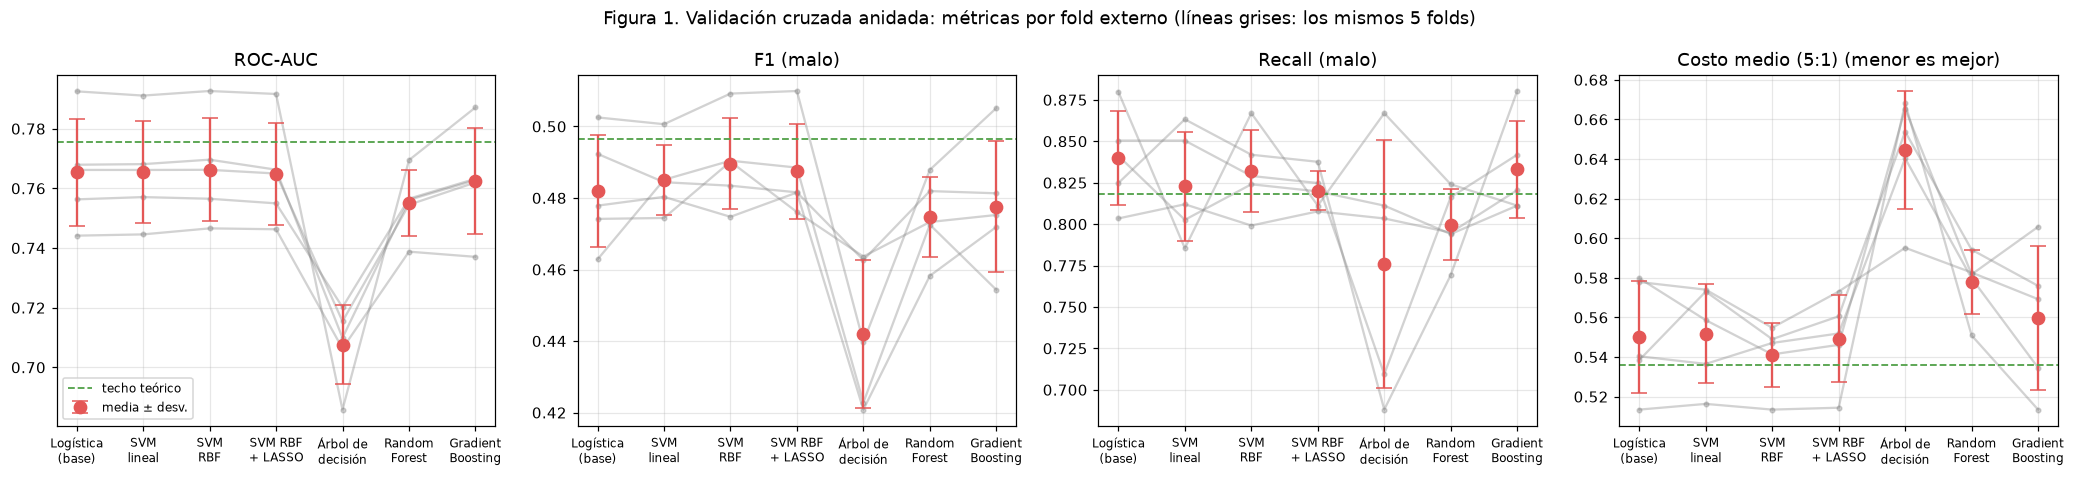

In [5]:
modelos_fig = [n for n in resultados if n != "Mayoría (línea base)"]
cortos = {BASE: "Logística\n(base)", "SVM lineal": "SVM\nlineal", "SVM RBF": "SVM\nRBF",
          "SVM RBF + selección LASSO": "SVM RBF\n+ LASSO", "Árbol de decisión": "Árbol de\ndecisión",
          "Random Forest": "Random\nForest", "Gradient Boosting": "Gradient\nBoosting"}
fig, axes = plt.subplots(1, 4, figsize=(19, 4.4))
for ax, m in zip(axes, ["ROC-AUC", "F1 (malo)", "Recall (malo)", "Costo medio (5:1)"]):
    x = np.arange(len(modelos_fig))
    for k in range(cv_externa.n_splits):
        ax.plot(x, [resultados[n]["folds"][m].iloc[k] for n in modelos_fig],
                color="gray", alpha=0.35, marker="o", markersize=3)
    ax.errorbar(x, media.loc[modelos_fig, m], yerr=desv.loc[modelos_fig, m], fmt="o",
                color="#E45756", capsize=5, markersize=8, label="media ± desv.")
    ax.axhline(media.loc[TECHO, m], color="#54A24B", linestyle="--", linewidth=1.2, label="techo teórico")
    ax.set_xticks(x)
    ax.set_xticklabels([cortos[n] for n in modelos_fig], fontsize=8)
    ax.set_title(m + (" (menor es mejor)" if "Costo" in m else ""))
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
fig.suptitle("Figura 1. Validación cruzada anidada: métricas por fold externo (líneas grises: los mismos 5 folds)")
fig.tight_layout()
fig.savefig(DIR_RES / "05_fig1_metricas_por_fold.png", bbox_inches="tight")
plt.show()

**Lectura de la tabla y de la Figura 1.**

- **Todos los modelos superan con claridad a la línea base de mayoría.** Esta
  tiene 77.5% de accuracy pero recall 0 y un costo de 1.12 por cliente, el doble
  que cualquier modelo. Es la confirmación más directa de por qué la accuracy no
  sirve como métrica principal: el modelo con mejor accuracy es el peor de todos.
- **Frente a la regresión logística, ningún modelo avanzado gana de forma
  significativa.**
  - El SVM RBF tiene el mejor ROC-AUC (0.766 ± 0.017), el mejor F1 (0.490) y el
    menor costo (0.541), pero su ventaja sobre la logística es de +0.001 de AUC
    (p = 0.29). Con selección LASSO queda igual (0.765, p = 0.60).
  - Los ensambles quedan por debajo: Gradient Boosting 0.762 y Random Forest
    0.755, con p-valores de 0.47 y 0.15.
- **El árbol de decisión es el único modelo significativamente peor que la
  logística** (ROC-AUC 0.708 ± 0.013, p = 0.04; costo 0.645, p = 0.05). Es la
  misma comparación que hace el artículo entre el SVM y los modelos
  tradicionales, y en este punto sí la reproducimos: un árbol individual queda
  muy por debajo del SVM.
- **Las diferencias entre los demás modelos son menores que las diferencias
  entre folds.** En la Figura 1 las líneas grises son casi paralelas: un mismo
  fold es "fácil" o "difícil" para todos los modelos, y la desviación entre folds
  (≈ 0.017 de AUC) es más de diez veces la diferencia entre la logística y el SVM
  RBF.
- **Todos, salvo el árbol, quedan muy cerca del techo teórico** (ROC-AUC
  0.775 ± 0.019; costo 0.536). El mejor modelo está a 0.009 de AUC y a 0.005 de
  costo del máximo alcanzable. Es el mismo resultado del notebook 04, ahora con
  una estimación sin sesgo de selección, y la razón de fondo del empate: la señal
  disponible en estas variables ya está casi agotada.
- **La validación anidada casi no cambia los números del notebook 04.** Allí el
  SVM RBF tenía 0.767 ± 0.015 con validación simple; aquí 0.766 ± 0.017. El sesgo
  optimista de elegir hiperparámetros en los mismos folds era pequeño, algo
  esperable porque la superficie de hiperparámetros es una meseta plana.

**¿Por qué los árboles y los ensambles no ganan?** La base simulada genera el
riesgo con un puntaje **aditivo** en escala logit, sin interacciones, cuya única
no linealidad es la forma en U leve de la edad. La ventaja típica de los árboles
es capturar interacciones y umbrales, y aquí no hay nada de eso que aprovechar.
Un árbol individual aproxima un efecto suave con pocos escalones y es inestable
(su recall varía ± 0.075 entre folds); el Random Forest reduce esa
inestabilidad promediando árboles, pero sigue cortando en escalones, y por eso
queda por debajo del boosting, que suma efectos pequeños. En datos reales de
crédito, donde sí hay interacciones (por ejemplo, monto × ingreso), el resultado
podría ser distinto. Esta es una limitación de la simulación, no una conclusión
general sobre los ensambles.

### 4.1 Estabilidad de los hiperparámetros

Si la validación anidada elige hiperparámetros muy distintos en cada fold
externo, el procedimiento es inestable y la media de la tabla promedia modelos
distintos. Por eso revisamos qué se eligió en cada fold.

In [6]:
hiper = pd.DataFrame({n: resultados[n]["folds"]["hiperparámetros"]
                      for n in resultados if MODELOS[n]["espacio"]})
hiper.index.name = "fold externo"
for n in hiper.columns:
    print(f"{n}:")
    for k, v in hiper[n].items():
        print(f"   fold {k}: {v}")
    print(f"   umbral de costo mínimo por fold: {np.round(resultados[n]['folds']['umbral'].to_numpy(), 3)}")

Regresión logística (línea base):
   fold 1: C=1
   fold 2: C=0.1
   fold 3: C=0.1
   fold 4: C=0.1
   fold 5: C=0.1
   umbral de costo mínimo por fold: [0.343 0.36  0.39  0.408 0.385]
SVM lineal:
   fold 1: C=0.1
   fold 2: C=0.01
   fold 3: C=0.01
   fold 4: C=0.01
   fold 5: C=0.01
   umbral de costo mínimo por fold: [-0.162 -0.14  -0.193 -0.209 -0.196]
SVM RBF:
   fold 1: gamma=0.01, C=1
   fold 2: gamma=0.01, C=1
   fold 3: gamma=0.01, C=1
   fold 4: gamma=0.01, C=1
   fold 5: gamma=0.03, C=0.3
   umbral de costo mínimo por fold: [-0.389 -0.534 -0.329 -0.421 -0.299]
SVM RBF + selección LASSO:
   fold 1: lasso_C=1, gamma=0.01, C=1
   fold 2: lasso_C=0.1, gamma=0.03, C=0.3
   fold 3: lasso_C=1, gamma=0.01, C=1
   fold 4: lasso_C=1, gamma=0.01, C=3
   fold 5: lasso_C=0.1, gamma=0.03, C=0.3
   umbral de costo mínimo por fold: [-0.388 -0.353 -0.311 -0.462 -0.37 ]
Árbol de decisión:
   fold 1: criterion=entropy, max_depth=5, min_samples_leaf=20
   fold 2: criterion=entropy, max_depth=6,

**Lectura.** Los hiperparámetros son estables en casi todos los modelos y
cuentan una historia coherente:

- **SVM RBF:** `C = 1, γ = 0.01` en 4 de 5 folds, el mismo óptimo del notebook
  04. El quinto fold elige `C = 0.3, γ = 0.03`, un vecino dentro de la misma
  meseta.
- **SVM RBF + LASSO:** la validación interna elige siempre los valores más altos
  de `lasso_C` (1 en tres folds y 0.1 en dos), es decir, la selección más débil:
  quitar columnas no mejora el modelo (Sección 6.0).
- **Gradient Boosting:** elige *stumps* (2 hojas) en 4 de 5 folds y 3 hojas en el
  otro. Es decir, **el boosting "descubre" por sí solo que la estructura es
  aditiva**, que es exactamente como se generaron los datos. Compensa la
  simpleza de cada árbol con muchas iteraciones (`max_iter = 600`, el máximo de
  la malla en todos los folds). Ampliar la malla podría ganar algo marginal, pero
  la Figura 1 muestra que el margen hasta el techo es de apenas 0.013 de AUC.
- **Random Forest:** siempre `max_features = sqrt`, `balanced_subsample` y hojas
  de al menos 10 clientes; solo varía la profundidad (6 o sin límite), que con
  esas hojas tiene poco efecto.
- **Árbol de decisión:** es el único inestable. La profundidad va de 4 a 10, el
  tamaño de hoja de 10 a 50 y el criterio cambia entre folds; su umbral de costo
  mínimo también es el que más varía (0.28 a 0.45). Es la conocida alta varianza
  de los árboles individuales, la razón por la que existen los ensambles.
- **Logística y SVM lineal:** regularización fuerte (`C = 0.1` y `C = 0.01`) en 4
  de 5 folds. Da casi igual, porque la curva de `C` es plana (notebook 04).
- **Umbral de costo mínimo:** salvo en el árbol, varía poco entre folds dentro
  de cada modelo; por ejemplo, entre 0.37 y 0.42 en probabilidad para Random
  Forest.

## 5. Selección del mejor modelo

Fijamos la regla antes de ver los resultados. Entre los modelos avanzados (no
las líneas base), el mejor es el de **mayor ROC-AUC medio en la validación
anidada**, redondeado a 3 decimales. Si hay empate, gana el de **menor costo
medio**. Elegimos el ROC-AUC como criterio principal porque es la métrica que no
depende del umbral, y el costo porque es el objetivo de negocio. Después
comprobamos si la ventaja del ganador es real, con la misma prueba corregida.

In [7]:
# Regla fijada antes de ver los resultados: entre los modelos avanzados, mayor ROC-AUC medio
# en la validación anidada (a 3 decimales); si hay empate, menor costo medio.
avanzados = [n for n in resultados if "línea base" not in n]
MEJOR = sorted(avanzados, key=lambda n: (-round(media.loc[n, "ROC-AUC"], 3), media.loc[n, "Costo medio (5:1)"]))[0]
print("Mejor modelo según la regla:", MEJOR)

# ¿Es la diferencia real? Prueba t corregida del mejor frente a cada uno de los demás
f_mejor = resultados[MEJOR]["folds"]
filas = {}
for n in resultados:
    if n in (MEJOR, "Mayoría (línea base)"):
        continue
    f = resultados[n]["folds"]
    filas[n] = {"Δ AUC (mejor − modelo)": (f_mejor["ROC-AUC"] - f["ROC-AUC"]).mean(),
                "p-valor AUC": p_valor_corregido(f_mejor["ROC-AUC"], f["ROC-AUC"], len(X_train), 5),
                "Δ costo (mejor − modelo)": (f_mejor["Costo medio (5:1)"] - f["Costo medio (5:1)"]).mean(),
                "p-valor costo": p_valor_corregido(f_mejor["Costo medio (5:1)"], f["Costo medio (5:1)"], len(X_train), 5)}
pd.DataFrame(filas).T.round(4)

Mejor modelo según la regla: SVM RBF


,Δ AUC (mejor − modelo),p-valor AUC,Δ costo (mejor − modelo),p-valor costo
Regresión logística (línea base),0.0009,0.2903,-0.0088,0.5655
SVM lineal,0.0009,0.2857,-0.0106,0.3295
SVM RBF + selección LASSO,0.0015,0.1233,-0.0081,0.1538
Árbol de decisión,0.0588,0.0365,-0.1035,0.0218
Random Forest,0.0112,0.1188,-0.0367,0.0012
Gradient Boosting,0.0039,0.4051,-0.0187,0.4004


**Lectura.** El mejor modelo es el **SVM RBF**, el método del artículo. Su
ventaja en ROC-AUC no es estadísticamente significativa frente a la logística,
el SVM lineal, el SVM con LASSO ni el Gradient Boosting (p entre 0.12 y 0.41).
Las diferencias significativas son dos:

- Frente al **árbol de decisión**, en AUC (+0.059, p = 0.04) y en costo (0.104
  menos por cliente, p = 0.02).
- Frente al **Random Forest**, en costo: 0.037 menos por cliente (p = 0.001).

Así que la conclusión honesta es doble:

- El SVM RBF es el mejor candidato, pero sin ventaja clara sobre los modelos
  lineales (logística y SVM lineal).
- El árbol de decisión y el Random Forest son las opciones menos convenientes
  para este problema.

Si en la sustentación se prefiere interpretabilidad, la logística o el SVM
lineal son alternativas prácticamente equivalentes.

## 6. Evaluación en test

Aplicamos a todo train el mismo procedimiento que se evaluó en cada fold
externo: búsqueda interna de hiperparámetros, umbral de costo mínimo y
reajuste. Solo entonces evaluamos una vez en test. El test confirma los
resultados, pero no los reemplaza: con 1.300 clientes (292 "malos") es una sola
partición, y la validación anidada, que promedia 5, es la estimación más
confiable.

In [8]:
t0 = time.time()
finales = {n: ajustar_modelo(construir_pipeline(cfg["modelo"], seleccionar=cfg.get("seleccion", False)),
                             cfg["espacio"], X_train, y_train,
                             cv_interna, n_iter=cfg["n_iter"], ajustar_umbral=cfg["umbral"], seed=SEED)
           for n, cfg in MODELOS.items()}
print(f"Tiempo: {time.time() - t0:.0f} s")

p_test = p_teorica[X_test.index.to_numpy()]
filas = {n: metricas(y_test, f.puntajes(X_test), f.predecir(X_test)) for n, f in finales.items()}
filas[TECHO] = metricas(y_test, p_test, (p_test >= 1 / 6).astype(int))
tabla_test = pd.DataFrame(filas).T[METRICAS].astype(float).round(3)
tabla_test["ROC-AUC anidada (media)"] = media["ROC-AUC"].round(3)
tabla_test["Hiperparámetros (train completo)"] = [
    ", ".join(f"{k}={v}" for k, v in finales[n].mejores_params.items()) if n in finales else "—"
    for n in tabla_test.index]
tabla_test.to_csv(DIR_RES / "05_tabla_test.csv")
tabla_test

Tiempo: 105 s


,F1 (malo),ROC-AUC,Recall (malo),Precisión (malo),Costo medio (5:1),Accuracy (ref.),ROC-AUC anidada (media),Hiperparámetros (train completo)
Mayoría (línea base),0.000,0.500,0.000,0.000,1.123,0.775,0.500,
Regresión logística (línea base),0.488,0.774,0.842,0.343,0.539,0.602,0.765,C=0.1
SVM lineal,0.483,0.774,0.846,0.338,0.545,0.594,0.765,C=0.01
SVM RBF,0.483,0.776,0.866,0.335,0.536,0.584,0.766,"gamma=0.01, C=1"
SVM RBF + selección LASSO,0.501,0.776,0.798,0.365,0.539,0.642,0.765,"lasso_C=1, gamma=0.01, C=1"
Árbol de decisión,0.473,0.737,0.784,0.339,0.586,0.608,0.708,"criterion=gini, max_depth=5, min_samples_leaf=100"
Random Forest,0.466,0.770,0.853,0.320,0.572,0.561,0.755,"min_samples_leaf=10, max_features=sqrt, max_depth=6, class_weight=balanced_subsample"
Gradient Boosting,0.493,0.773,0.856,0.346,0.525,0.604,0.762,"min_samples_leaf=50, max_leaf_nodes=3, max_iter=600, learning_rate=0.03, l2_regularization=1"
Techo teórico: P(malo | x),0.502,0.776,0.836,0.359,0.520,0.628,0.775,—


**Lectura.** El test confirma el panorama general de la validación anidada,
aunque en una sola partición el orden fino entre modelos cambia:

- El SVM RBF alcanza **ROC-AUC 0.776**, igual al techo teórico en test (0.776), y
  el recall de "malo" más alto (0.866): detecta a 253 de los 292 clientes
  riesgosos.
- El **menor costo en test es el del Gradient Boosting (0.525)**, seguido del
  SVM RBF (0.536) y de la logística y el SVM con LASSO (0.539). En la validación
  anidada, en cambio, el boosting costaba más que el SVM RBF (0.560 frente a
  0.541). Diferencias de 0.01 en el costo están dentro del ruido de una sola
  partición de test: el intervalo bootstrap del costo tiene un ancho de ~0.10
  (Sección 8.2). Por eso la selección se basa en la validación anidada, que
  promedia 5 particiones, y no en el test.
- El SVM con LASSO tiene el mejor F1 (0.501) y la mayor precisión (0.365),
  porque su umbral lo lleva a rechazar a menos clientes; a cambio, su recall es
  menor (0.798).
- El árbol de decisión sigue siendo claramente el peor modelo (ROC-AUC 0.737;
  costo 0.586), y el Random Forest el ensamble más costoso (0.572).

Los hiperparámetros elegidos con todo train coinciden con los de la mayoría de
los folds externos, otra señal de estabilidad. Las excepciones son el Gradient
Boosting, que elige árboles de 3 hojas como en el fold 5, y el árbol de
decisión, cuyo resultado varía de un fold a otro.

### 6.0 ¿Ayuda la selección de variables?

Revisamos qué columnas conserva el LASSO en el modelo final y si la selección
mejora al SVM RBF sin selección en la validación anidada.

In [9]:
sel = finales["SVM RBF + selección LASSO"].estimador
mascara = sel.named_steps["seleccion"].get_support()
columnas = sel.named_steps["codificar"].get_feature_names_out()
print(f"Columnas conservadas por el LASSO en el modelo final: {mascara.sum()} de {len(mascara)} "
      f"(lasso_C = {finales['SVM RBF + selección LASSO'].mejores_params['lasso_C']})")
print("Columnas descartadas:", list(columnas[~mascara]))
print("lasso_C elegido en cada fold externo:",
      [h.split("lasso_C=")[1].split(",")[0] for h in resultados["SVM RBF + selección LASSO"]["folds"]["hiperparámetros"]])

f_sel, f_rbf = resultados["SVM RBF + selección LASSO"]["folds"], resultados["SVM RBF"]["folds"]
for m in ["ROC-AUC", "Costo medio (5:1)"]:
    print(f"{m}: con selección {f_sel[m].mean():.4f} | sin selección {f_rbf[m].mean():.4f} | "
          f"p-valor corregido {p_valor_corregido(f_sel[m], f_rbf[m], len(X_train), 5):.2f}")

Columnas conservadas por el LASSO en el modelo final: 30 de 32 (lasso_C = 1)
Columnas descartadas: ['tipo_vivienda_familiar', 'proposito_credito_remodelacion']
lasso_C elegido en cada fold externo: ['1', '0.1', '1', '1', '0.1']
ROC-AUC: con selección 0.7648 | sin selección 0.7663 | p-valor corregido 0.12
Costo medio (5:1): con selección 0.5492 | sin selección 0.5412 | p-valor corregido 0.15


**Lectura.** La selección LASSO no ayuda en esta base:

- Con el `lasso_C` que elige la validación (1), el LASSO conserva **30 de las 32
  columnas** y solo descarta `tipo_vivienda = familiar` y `proposito_credito =
  remodelacion`. La segunda es justamente una categoría con efecto nulo en la
  simulación, lo que muestra que el LASSO funciona como se espera.
- En la validación anidada, el SVM con selección no mejora al SVM sin ella
  (ROC-AUC 0.765 frente a 0.766, p = 0.12; costo 0.549 frente a 0.541, p = 0.15).

La razón es que la base tiene pocas variables (11) y casi todas afectan el
riesgo por construcción, así que hay poco que descartar. En el artículo la
selección tiene sentido porque se combina con ingeniería de características que
multiplica las variables candidatas. Aquí mantenemos el SVM RBF sin selección
como modelo principal, por ser más simple con el mismo desempeño.

### 6.1 Matrices de confusión

Mostramos las de los siete modelos en test y, para el mejor, además la matriz
agregada de la validación anidada. Esta suma las predicciones fuera de fold de
los 5.200 clientes de train, así que es más estable que la de test.

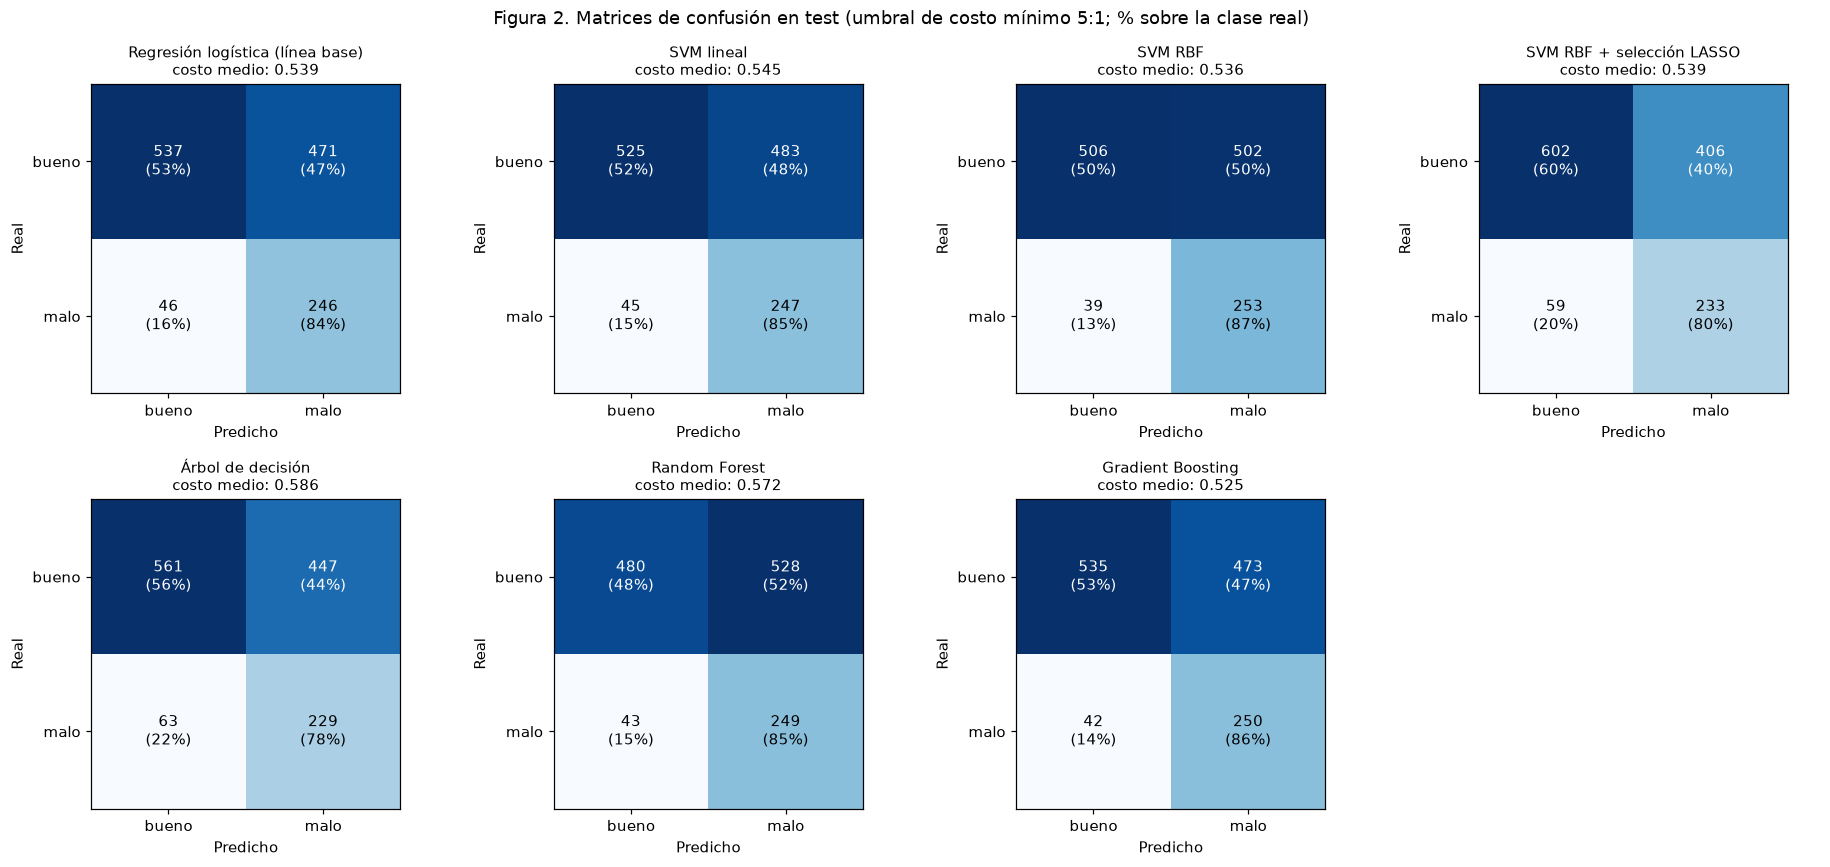

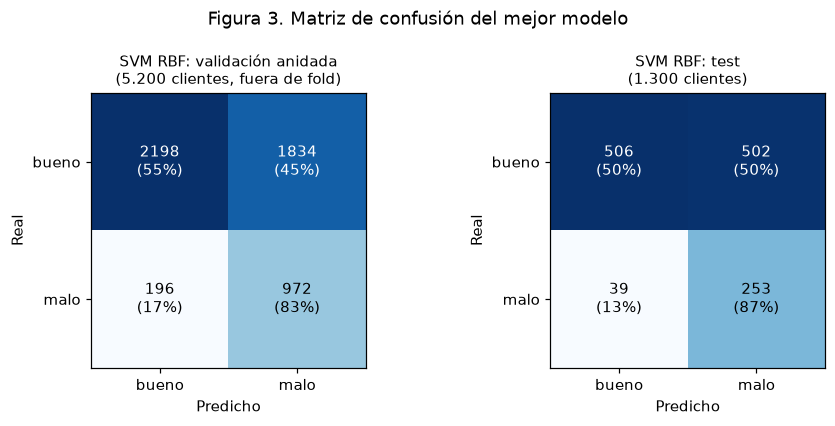

In [10]:
def dibujar_cm(ax, cm, titulo):
    ax.imshow(cm, cmap="Blues")
    tot = cm.sum(axis=1, keepdims=True)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]}\n({cm[i, j] / tot[i, 0]:.0%})", ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=10)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["bueno", "malo"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["bueno", "malo"])
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
    ax.set_title(titulo, fontsize=9.5)

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for ax, n in zip(axes.ravel(), modelos_fig):
    pred = finales[n].predecir(X_test)
    dibujar_cm(ax, confusion_matrix(y_test, pred), f"{n}\ncosto medio: {costo_medio(y_test, pred):.3f}")
for ax in axes.ravel()[len(modelos_fig):]:
    ax.axis("off")
fig.suptitle("Figura 2. Matrices de confusión en test (umbral de costo mínimo 5:1; % sobre la clase real)")
fig.tight_layout()
fig.savefig(DIR_RES / "05_fig2_matrices_test.png", bbox_inches="tight")
plt.show()

oof = resultados[MEJOR]["oof"]
fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.9))
dibujar_cm(axes[0], confusion_matrix(oof["y"], oof["pred"]),
           f"{MEJOR}: validación anidada\n(5.200 clientes, fuera de fold)")
dibujar_cm(axes[1], confusion_matrix(y_test, finales[MEJOR].predecir(X_test)),
           f"{MEJOR}: test\n(1.300 clientes)")
fig.suptitle("Figura 3. Matriz de confusión del mejor modelo")
fig.tight_layout()
fig.savefig(DIR_RES / "05_fig3_matriz_mejor.png", bbox_inches="tight")
plt.show()

**Lectura de las Figuras 2 y 3.** Con el umbral de costo mínimo, todos los
modelos siguen la misma lógica: detectan entre el 78% (árbol de decisión) y el
87% (SVM RBF) de los "malos", a cambio de rechazar a una parte importante de los
"buenos" (la mitad en el caso del SVM RBF). Eso es lo que pide la matriz 5:1:
rechazar a un cliente bueno cuesta 1, mientras que aprobar a uno malo cuesta 5,
así que conviene rechazar ante la duda.

En el SVM RBF, la matriz agregada de la validación anidada y la de test tienen
proporciones muy parecidas (recall de 83% y 87%). El comportamiento del modelo
no depende de una partición afortunada.

## 7. Análisis de errores del mejor modelo

Analizamos los errores del SVM RBF en test con tres preguntas:

1. ¿Qué tan evitables son sus errores?
2. ¿En qué perfiles se concentran?
3. ¿Los demás modelos se equivocan con los mismos clientes?

Como la base es simulada, para la primera pregunta usamos la probabilidad
teórica $P(\text{malo} \mid x)$ de cada cliente. Si un cliente "malo" tiene una
probabilidad teórica baja, ni siquiera un modelo perfecto lo habría detectado:
ese error es **irreducible**, fruto del ruido idiosincrático de la simulación.

In [11]:
mejor = finales[MEJOR]
det = X_test.copy()
det["real"] = y_test
det["pred"] = mejor.predecir(X_test)
det["p_teorica"] = p_test
det["tipo"] = np.select(
    [(det.real == 1) & (det.pred == 1), (det.real == 1) & (det.pred == 0), (det.real == 0) & (det.pred == 1)],
    ["VP (malo detectado)", "FN (malo aprobado)", "FP (bueno rechazado)"], "VN (bueno aprobado)")

bayes = (p_test >= 1 / 6).astype(int)
resumen_err = det.groupby("tipo").agg(clientes=("real", "size"),
                                      p_teorica_mediana=("p_teorica", "median"),
                                      p_teorica_media=("p_teorica", "mean"))
n_test = len(det)
resumen_err["costo aportado (por cliente de test)"] = [
    5 * c / n_test if t.startswith("FN") else (c / n_test if t.startswith("FP") else 0.0)
    for t, c in zip(resumen_err.index, resumen_err["clientes"])]
print("Costo total por cliente:", round(resumen_err["costo aportado (por cliente de test)"].sum(), 3))

fn = det["tipo"].str.startswith("FN")
fp = det["tipo"].str.startswith("FP")
print(f"Falsos negativos que la regla de Bayes (con la estructura verdadera) también aprobaría: "
      f"{(bayes[fn.to_numpy()] == 0).mean():.0%}")
print(f"Falsos positivos que la regla de Bayes también rechazaría: {(bayes[fp.to_numpy()] == 1).mean():.0%}")
print(f"Coincidencia de decisiones entre {MEJOR} y la regla de Bayes: {(det['pred'].to_numpy() == bayes).mean():.1%}")
resumen_err.round(3)

Costo total por cliente: 0.536
Falsos negativos que la regla de Bayes (con la estructura verdadera) también aprobaría: 85%
Falsos positivos que la regla de Bayes también rechazaría: 82%
Coincidencia de decisiones entre SVM RBF y la regla de Bayes: 89.9%


,clientes,p_teorica_mediana,p_teorica_media,costo aportado (por cliente de test)
tipo,,,,
FN (malo aprobado),39,0.105,0.113,0.150
FP (bueno rechazado),502,0.258,0.292,0.386
VN (bueno aprobado),506,0.076,0.082,0.000
VP (malo detectado),253,0.379,0.404,0.000


**Lectura.** De los 39 falsos negativos (clientes malos aprobados), el **85%
también los habría aprobado la regla de Bayes** con la estructura verdadera. Su
probabilidad teórica mediana es 0.105, por debajo del umbral de 1/6: son clientes
con perfil de bajo riesgo que igual cayeron en mora.

Lo mismo ocurre con los falsos positivos. El 82% los habría rechazado también la
regla de Bayes: son clientes con perfil riesgoso (mediana 0.258) que pagaron
bien. En total, las decisiones del SVM RBF coinciden con las de la regla óptima
en el **89.9%** de los clientes de test.

Los falsos positivos aportan el 72% del costo (0.386 de 0.536 por cliente). Aun
con la penalización 5:1, el costo dominante es rechazar a buenos clientes.

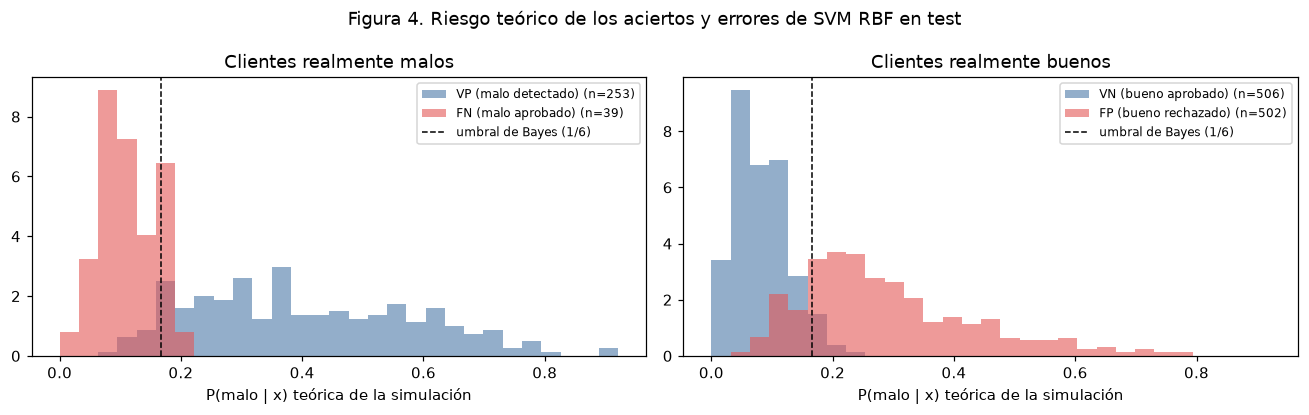

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=False)
bins = np.linspace(0, p_test.max(), 30)
for ax, (a, b) in zip(axes, [("VP (malo detectado)", "FN (malo aprobado)"),
                             ("VN (bueno aprobado)", "FP (bueno rechazado)")]):
    for t, color in [(a, "#4C78A8"), (b, "#E45756")]:
        ax.hist(det.loc[det.tipo == t, "p_teorica"], bins=bins, alpha=0.6, color=color, density=True,
                label=f"{t} (n={int((det.tipo == t).sum())})")
    ax.axvline(1 / 6, color="black", linestyle="--", linewidth=1, label="umbral de Bayes (1/6)")
    ax.set_xlabel("P(malo | x) teórica de la simulación")
    ax.legend(fontsize=8)
axes[0].set_title("Clientes realmente malos")
axes[1].set_title("Clientes realmente buenos")
fig.suptitle(f"Figura 4. Riesgo teórico de los aciertos y errores de {MEJOR} en test")
fig.tight_layout()
fig.savefig(DIR_RES / "05_fig4_errores_riesgo_teorico.png", bbox_inches="tight")
plt.show()

**Lectura de la Figura 4.**

- En los clientes realmente malos, los falsos negativos (rojo) se concentran a la
  izquierda del umbral de Bayes, mientras que los malos detectados se reparten
  hacia la derecha.
- En los realmente buenos pasa lo simétrico: los rechazados tienen riesgo
  teórico alto.

El modelo se equivoca donde el perfil observable "miente", no porque ordene mal
a los clientes.

### 7.1 Errores por segmento

Revisamos el recall y los falsos negativos en las tres variables más influyentes,
y la tasa de rechazo de clientes buenos, que es el costo comercial del modelo.

In [13]:
def por_segmento(col):
    g = det.groupby(col, observed=True)
    return pd.DataFrame({
        "clientes": g.size(),
        "% malo real": g["real"].mean(),
        "recall (malo)": g.apply(lambda d: d.loc[d.real == 1, "pred"].mean(), include_groups=False),
        "FN": g.apply(lambda d: ((d.real == 1) & (d.pred == 0)).sum(), include_groups=False),
        "tasa de rechazo de buenos": g.apply(lambda d: d.loc[d.real == 0, "pred"].mean(), include_groups=False),
    })

for col in ["estado_pago_previo", "saldo_categoria", "tipo_ocupacion"]:
    print(f"\n=== {col} ===")
    print(por_segmento(col).sort_values("% malo real").round(3).to_string())

print("\nNuméricas (mediana) por tipo de resultado:")
print(det.groupby("tipo")[["plazo_meses", "monto_credito_cop", "edad"]].median().round(0).to_string())


=== estado_pago_previo ===
                      clientes  % malo real  recall (malo)  FN  tasa de rechazo de buenos
estado_pago_previo                                                                       
al_dia                     704        0.126          0.629  33                      0.263
sin_creditos_previos       123        0.220          0.926   2                      0.740
mora_leve                  106        0.330          0.971   1                      0.789
mora_severa                367        0.384          0.979   3                      0.942

=== saldo_categoria ===
                 clientes  % malo real  recall (malo)  FN  tasa de rechazo de buenos
saldo_categoria                                                                     
alto                   82        0.024          0.500   1                      0.325
medio                 329        0.146          0.708  14                      0.359
bajo                  378        0.217          0.915   7          

**Lectura.**

- **Los falsos negativos se concentran en clientes con historial al día:** 33 de
  los 39. En ese segmento el recall baja a 0.63, frente a más de 0.92 en los
  demás. Es el grupo con menor tasa de "malo" (12.6%), así que sus "malos" son
  los más difíciles de distinguir. También son los más costosos de detectar:
  habría que rechazar a muchos buenos pagadores.
- **En mora severa, el modelo rechaza al 94% de los clientes buenos.** En la
  práctica equivale a la regla "rechazar a todo el que tuvo mora severa". Es
  coherente con la matriz 5:1 (el 38% de ese segmento es "malo"), pero en un
  contexto real sería una decisión de política crediticia con consecuencias de
  inclusión financiera, que el equipo debería explicitar.
- **Lo mismo ocurre con la cuenta bancaria.** Se rechaza al 61% de los buenos
  clientes sin cuenta, frente al 33% con saldo alto. La adaptación colombiana
  ("no tener cuenta aumenta el riesgo", notebook 04) se traduce directamente en
  menos aprobaciones para la población no bancarizada.
- **En las numéricas,** los falsos negativos piden créditos más cortos y pequeños
  que los malos detectados (plazo mediano de 18 frente a 24 meses; monto de 3.7
  frente a 5.8 millones). Se parecen más a los buenos aprobados, lo que confirma
  que su perfil es de bajo riesgo.

In [14]:
# ¿Los distintos modelos se equivocan con los mismos clientes?
fn_sets = {n: set(X_test.index[(y_test == 1) & (finales[n].predecir(X_test) == 0)]) for n in modelos_fig}
fn_sets["Regla de Bayes (techo)"] = set(X_test.index[(y_test == 1) & (bayes == 0)])
nombres = list(fn_sets)
jaccard = pd.DataFrame([[len(fn_sets[a] & fn_sets[b]) / max(len(fn_sets[a] | fn_sets[b]), 1) for b in nombres]
                        for a in nombres], index=nombres, columns=nombres)
print("Número de falsos negativos por modelo:", {n: len(s) for n, s in fn_sets.items()})
print(f"Falsos negativos comunes a los {len(modelos_fig)} modelos: "
      f"{len(set.intersection(*[fn_sets[n] for n in modelos_fig]))}")
print(f"Falsos negativos de {MEJOR} que también comete al menos otro modelo: "
      f"{len(fn_sets[MEJOR] & set.union(*[fn_sets[n] for n in modelos_fig if n != MEJOR]))} de {len(fn_sets[MEJOR])}")
print("\nÍndice de Jaccard entre los conjuntos de falsos negativos:")
jaccard.round(2)

Número de falsos negativos por modelo: {'Regresión logística (línea base)': 46, 'SVM lineal': 45, 'SVM RBF': 39, 'SVM RBF + selección LASSO': 59, 'Árbol de decisión': 63, 'Random Forest': 43, 'Gradient Boosting': 42, 'Regla de Bayes (techo)': 48}
Falsos negativos comunes a los 7 modelos: 24
Falsos negativos de SVM RBF que también comete al menos otro modelo: 39 de 39

Índice de Jaccard entre los conjuntos de falsos negativos:


,Regresión logística (línea base),SVM lineal,SVM RBF,SVM RBF + selección LASSO,Árbol de decisión,Random Forest,Gradient Boosting,Regla de Bayes (techo)
Regresión logística (línea base),1.00,0.94,0.77,0.75,0.43,0.62,0.69,0.65
SVM lineal,0.94,1.00,0.79,0.76,0.42,0.63,0.67,0.63
SVM RBF,0.77,0.79,1.00,0.66,0.44,0.64,0.76,0.61
SVM RBF + selección LASSO,0.75,0.76,0.66,1.00,0.54,0.62,0.60,0.62
Árbol de decisión,0.43,0.42,0.44,0.54,1.00,0.43,0.42,0.42
Random Forest,0.62,0.63,0.64,0.62,0.43,1.00,0.73,0.57
Gradient Boosting,0.69,0.67,0.76,0.60,0.42,0.73,1.00,0.61
Regla de Bayes (techo),0.65,0.63,0.61,0.62,0.42,0.57,0.61,1.00


**Lectura.** Los modelos se equivocan en gran medida con **los mismos
clientes**:

- El SVM RBF es el que menos falsos negativos comete (39). Los 39 los comete
  también al menos otro modelo, y 24 son comunes a los siete modelos.
- El índice de Jaccard entre la logística, el SVM lineal y los dos SVM RBF va de
  0.66 a 0.94, y con la regla de Bayes, de 0.57 a 0.65 en todos los modelos
  salvo el árbol.
- El árbol de decisión es la excepción (Jaccard ≈ 0.42–0.54 con los demás): sus
  errores adicionales vienen de su propia inestabilidad, no de los clientes
  difíciles.

Cambiar de modelo, o combinarlos, no recuperaría a esos clientes. Para
detectarlos haría falta **información nueva**: ingresos, endeudamiento en
centrales de riesgo o comportamiento transaccional. No hace falta un algoritmo
más complejo.

## 8. Primera lectura del mejor modelo: importancia de variables

El SVM RBF no tiene coeficientes interpretables, así que usamos la **importancia
por permutación**. Para cada variable original, desordenamos sus valores entre
clientes y medimos cuánto cae el ROC-AUC. Si el modelo depende de esa variable,
la caída es grande. Tiene tres ventajas:

- Es agnóstica al modelo, así que se puede comparar entre SVM, logística y
  ensambles.
- Se mide sobre las **11 variables originales**, no sobre las 32 columnas
  one-hot, porque permutamos antes del `Pipeline`.
- La calculamos en **cada fold externo** de la validación anidada, con 10
  repeticiones, sobre clientes que el modelo no vio. Así obtenemos a la vez la
  importancia y su estabilidad.

Preferimos la permutación sobre SHAP porque el `KernelExplainer` de SHAP para un
SVM RBF es muy costoso y, además, exigiría una dependencia nueva.

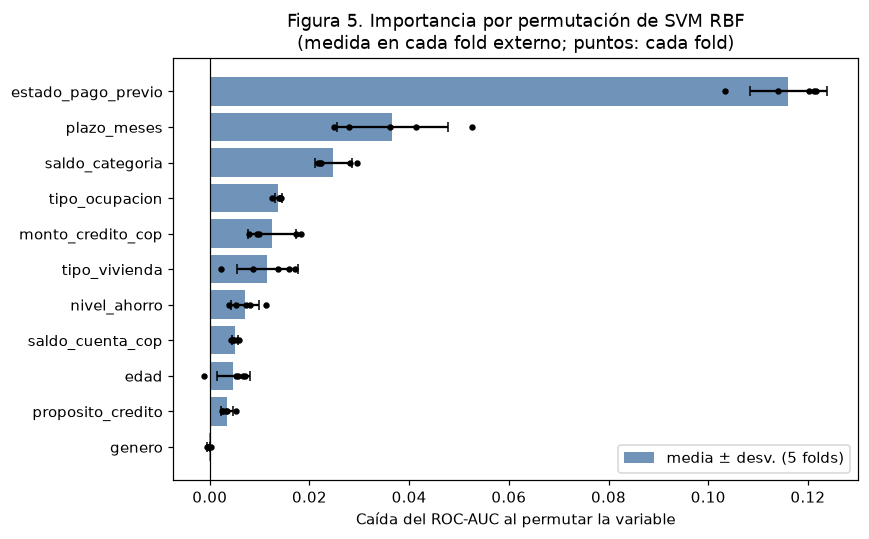

Spearman medio entre los rankings de los 5 folds: 0.887 (mín. 0.736)
Veces que cada variable queda en el top 5 (de 5 folds):
estado_pago_previo    5
plazo_meses           5
saldo_categoria       5
monto_credito_cop     4
tipo_vivienda         3
tipo_ocupacion        3
edad                  0
genero                0
nivel_ahorro          0
saldo_cuenta_cop      0
proposito_credito     0


In [15]:
imp = resultados[MEJOR]["importancias"]              # filas: folds externos; columnas: variables
orden = imp.mean().sort_values().index
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(orden, imp[orden].mean(), xerr=imp[orden].std(ddof=1), color="#4C78A8", alpha=0.8,
        capsize=3, label="media ± desv. (5 folds)")
for k in imp.index:
    ax.scatter(imp.loc[k, orden], orden, color="black", s=10, zorder=3)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Caída del ROC-AUC al permutar la variable")
ax.set_title(f"Figura 5. Importancia por permutación de {MEJOR}\n(medida en cada fold externo; puntos: cada fold)")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(DIR_RES / "05_fig5_importancia_mejor.png", bbox_inches="tight")
plt.show()

# Estabilidad del ranking entre folds
rangos = imp.rank(axis=1, ascending=False)
top5 = (rangos <= 5).sum().sort_values(ascending=False)
pares = [spearmanr(imp.iloc[a], imp.iloc[b])[0] for a in range(len(imp)) for b in range(a + 1, len(imp))]
print(f"Spearman medio entre los rankings de los 5 folds: {np.mean(pares):.3f} (mín. {np.min(pares):.3f})")
print("Veces que cada variable queda en el top 5 (de 5 folds):")
print(top5.to_string())

**Lectura de la Figura 5 y estabilidad.**

- **El historial de pago previo es, de lejos, la variable más importante.**
  Permutarlo baja el ROC-AUC en ≈ 0.12, casi tanto como todas las demás juntas.
- Le siguen el **plazo** (0.037) y la **categoría de saldo** (0.025), y después,
  muy parejos, la ocupación, el monto y la vivienda (0.012 a 0.014).
- El género, el saldo en pesos y el propósito casi no aportan.

El ranking es **estable**:
- La correlación de Spearman media entre los rankings de los 5 folds es 0.89.
- Historial de pago, plazo y categoría de saldo están en el top 5 en los 5 folds;
  el monto, en 4.
- Las barras de error son pequeñas frente a las diferencias entre las variables
  principales.

La lectura coincide en buena medida con el artículo. Xu y Cheng destacan el
saldo de la cuenta, la duración, el historial de pago, el propósito y el monto.
Cuatro de esas cinco están entre las cinco variables más importantes de nuestro
SVM RBF (historial, plazo, saldo y monto); el propósito, en cambio, casi no
aporta en nuestra base.

### 8.1 Contraste con la estructura verdadera de la simulación

Como construimos los datos, podemos calcular la **importancia verdadera** de
cada variable. Aplicamos la misma permutación al puntaje con que se generó el
riesgo (sin ruido) y medimos la misma caída de ROC-AUC. Si un modelo aprendió la
estructura correcta, su importancia debería parecerse a esta.

Spearman de cada modelo con la importancia verdadera: {'Regresión logística (línea base)': 0.897, 'SVM lineal': 0.897, 'SVM RBF': 0.916, 'SVM RBF + selección LASSO': 0.957, 'Árbol de decisión': 0.492, 'Random Forest': 0.802, 'Gradient Boosting': 0.538}


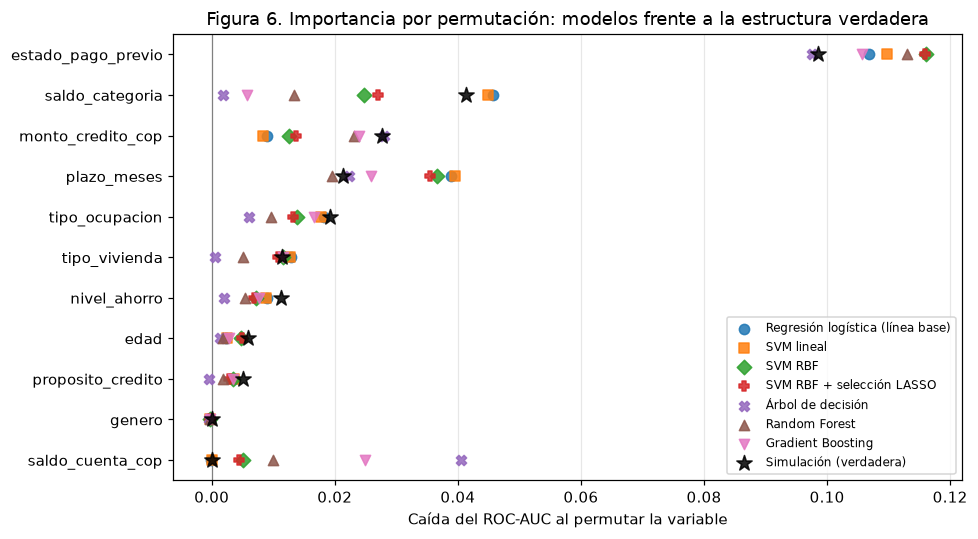

,Regresión logística (línea base),SVM lineal,SVM RBF,SVM RBF + selección LASSO,Árbol de decisión,Random Forest,Gradient Boosting,Simulación (verdadera)
estado_pago_previo,0.1068,0.1098,0.1161,0.1158,0.0976,0.1130,0.1056,0.0986
saldo_categoria,0.0457,0.0449,0.0248,0.0270,0.0018,0.0134,0.0057,0.0414
monto_credito_cop,0.0090,0.0083,0.0125,0.0137,0.0279,0.0232,0.0240,0.0276
plazo_meses,0.0389,0.0395,0.0366,0.0355,0.0223,0.0196,0.0259,0.0214
tipo_ocupacion,0.0182,0.0178,0.0138,0.0132,0.0060,0.0097,0.0166,0.0192
tipo_vivienda,0.0130,0.0128,0.0115,0.0108,0.0005,0.0050,0.0116,0.0113
nivel_ahorro,0.0091,0.0088,0.0071,0.0068,0.0019,0.0054,0.0077,0.0113
edad,0.0023,0.0025,0.0047,0.0049,0.0013,0.0018,0.0028,0.0060
proposito_credito,0.0037,0.0037,0.0034,0.0028,-0.0004,0.0018,0.0034,0.0051
genero,-0.0003,-0.0003,-0.0002,-0.0002,-0.0004,-0.0003,-0.0003,0.0000


In [16]:
# Importancia "verdadera": la misma permutación aplicada al puntaje observable de la simulación.
# El ROC-AUC no cambia con transformaciones monótonas, así que basta con el puntaje latente
# sin ruido (la P(malo | x) es una función creciente de él). Se usa la base sin faltantes.
rng = np.random.default_rng(SEED)
base_tr = base_sin_faltantes.loc[X_train.index]
auc_ref = roc_auc_score(y_train, puntaje_latente(base_tr, incluir_ruido=False))
imp_teorica = {}
for col in X_train.columns:
    caidas = []
    for _ in range(10):
        perm = base_tr.copy()
        perm[col] = rng.permutation(perm[col].to_numpy())
        caidas.append(auc_ref - roc_auc_score(y_train, puntaje_latente(perm, incluir_ruido=False)))
    imp_teorica[col] = np.mean(caidas)
imp_teorica = pd.Series(imp_teorica)

comp = pd.DataFrame({n: resultados[n]["importancias"].mean() for n in modelos_fig})
comp["Simulación (verdadera)"] = imp_teorica
comp = comp.sort_values("Simulación (verdadera)", ascending=False)
rho = {n: spearmanr(comp[n], comp["Simulación (verdadera)"])[0] for n in modelos_fig}
print("Spearman de cada modelo con la importancia verdadera:",
      {n: round(float(r), 3) for n, r in rho.items()})

fig, ax = plt.subplots(figsize=(9, 5))
y_pos = np.arange(len(comp))
marcas = dict(zip(modelos_fig + ["Simulación (verdadera)"], ["o", "s", "D", "P", "X", "^", "v", "*"]))
for n, mk in marcas.items():
    ax.scatter(comp[n], y_pos, marker=mk, s=110 if mk == "*" else 45,
               color="black" if mk == "*" else None, label=n, alpha=0.85, zorder=3)
ax.set_yticks(y_pos); ax.set_yticklabels(comp.index)
ax.invert_yaxis()
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Caída del ROC-AUC al permutar la variable")
ax.set_title("Figura 6. Importancia por permutación: modelos frente a la estructura verdadera")
ax.grid(axis="x", alpha=0.3)
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
fig.savefig(DIR_RES / "05_fig6_importancia_modelos_vs_verdadera.png", bbox_inches="tight")
plt.show()
comp.round(4)

**Lectura de la Figura 6.** Los modelos basados en SVM son los que mejor
recuperan la importancia verdadera: el SVM RBF con LASSO (Spearman 0.96) y el SVM
RBF (0.92), seguidos de la logística y el SVM lineal (0.90). Más abajo quedan el
Random Forest (0.80), el Gradient Boosting (0.54) y el árbol de decisión (0.49).
Esta comparación deja tres aprendizajes:

- **Todos identifican bien la variable dominante** (historial de pago) y todos
  asignan importancia nula al género, que en la simulación no tiene efecto. Es
  una buena señal de que ningún modelo aprendió relaciones espurias con una
  variable sensible.
- **La edad:** los SVM RBF le dan más importancia (0.005) que los modelos
  lineales (0.002), más cerca del valor verdadero (0.006). Es la huella de la
  forma en U, que un kernel no lineal puede capturar y una recta no.
- **El Spearman bajo de los árboles no significa necesariamente que aprendieron
  mal.** Se debe en buena parte a **variables redundantes**. El saldo en pesos y
  su categoría llevan casi la misma información (saldo 0 equivale a "sin
  cuenta"). El boosting y el árbol cortan directamente sobre el saldo en pesos
  (importancia 0.025 y 0.040) y casi ignoran la categoría (0.006 y 0.002),
  mientras que en la simulación el riesgo entra por la categoría. Al permutar
  solo una de las dos, la otra "cubre" su ausencia, y la importancia se reparte
  de forma distinta según el modelo. Lo mismo pasa entre monto y plazo
  (correlación 0.60).

Para corregir ese sesgo de la permutación individual, permutamos las variables
redundantes **en grupo**.

In [17]:
# Permutación por grupos: variables que llevan la misma información se permutan juntas
GRUPOS = {
    "saldo (categoría + monto COP)": ["saldo_categoria", "saldo_cuenta_cop"],
    "crédito (plazo + monto)": ["plazo_meses", "monto_credito_cop"],
    "estado_pago_previo": ["estado_pago_previo"],
    "tipo_ocupacion": ["tipo_ocupacion"],
    "nivel_ahorro": ["nivel_ahorro"],
    "tipo_vivienda": ["tipo_vivienda"],
    "proposito_credito": ["proposito_credito"],
    "edad": ["edad"],
    "genero": ["genero"],
}
rng = np.random.default_rng(SEED)
auc_base = roc_auc_score(y_test, mejor.puntajes(X_test))
filas = {}
for g, cols in GRUPOS.items():
    caidas = []
    for _ in range(20):
        perm = X_test.copy()
        orden_perm = rng.permutation(len(perm))
        perm[cols] = perm[cols].to_numpy()[orden_perm]
        caidas.append(auc_base - roc_auc_score(y_test, mejor.puntajes(perm)))
    filas[g] = {"caída de ROC-AUC (media)": np.mean(caidas), "desv.": np.std(caidas, ddof=1)}
imp_grupos = pd.DataFrame(filas).T.sort_values("caída de ROC-AUC (media)", ascending=False)
print(f"ROC-AUC de {MEJOR} en test sin permutar: {auc_base:.3f}")
print("Suma de las importancias individuales de saldo_categoria y saldo_cuenta_cop (validación anidada):",
      round(resultados[MEJOR]["importancias"][["saldo_categoria", "saldo_cuenta_cop"]].mean().sum(), 4))
imp_grupos.round(4)

ROC-AUC de SVM RBF en test sin permutar: 0.776
Suma de las importancias individuales de saldo_categoria y saldo_cuenta_cop (validación anidada): 0.0298


,caída de ROC-AUC (media),desv.
estado_pago_previo,0.1210,0.0111
crédito (plazo + monto),0.0723,0.0077
saldo (categoría + monto COP),0.0529,0.0073
tipo_ocupacion,0.0107,0.0040
nivel_ahorro,0.0062,0.0036
tipo_vivienda,0.0029,0.0031
proposito_credito,0.0020,0.0015
genero,-0.0002,0.0003
edad,-0.0006,0.0020


**Lectura.**

- **El saldo gana peso al permutarlo en grupo.** Categoría y monto en COP juntos
  bajan el AUC en 0.053, casi el doble que la suma de sus importancias
  individuales (0.030). Sin agrupar, la importancia del saldo quedaba
  subestimada.
- **El crédito solicitado (plazo + monto) es el segundo factor** (0.072).
- **El orden final** es historial de pago, condiciones del crédito, cuenta
  bancaria, ocupación, ahorro y vivienda.

Esta es la lectura que conviene presentar en el informe, porque no depende de
cómo cada modelo reparte la información entre variables correlacionadas.

### 8.2 Incertidumbre en test

Para dimensionar cuánto puede variar el resultado en test, remuestreamos los
1.300 clientes con reemplazo 1.000 veces (bootstrap). También calculamos la
diferencia con la logística sobre los mismos remuestreos.

In [18]:
# Intervalos bootstrap (1.000 remuestreos del test) del mejor modelo y de su diferencia con la logística
rng = np.random.default_rng(SEED)
punt_m, pred_m = mejor.puntajes(X_test), mejor.predecir(X_test)
punt_b, pred_b = finales[BASE].puntajes(X_test), finales[BASE].predecir(X_test)
boot = []
for _ in range(1000):
    i = rng.integers(0, len(y_test), len(y_test))
    mm, mb = metricas(y_test[i], punt_m[i], pred_m[i]), metricas(y_test[i], punt_b[i], pred_b[i])
    boot.append({**{m: mm[m] for m in ["ROC-AUC", "F1 (malo)", "Recall (malo)", "Costo medio (5:1)"]},
                 "Δ ROC-AUC vs. logística": mm["ROC-AUC"] - mb["ROC-AUC"],
                 "Δ costo vs. logística": mm["Costo medio (5:1)"] - mb["Costo medio (5:1)"]})
boot = pd.DataFrame(boot)
pd.DataFrame({"percentil 2.5": boot.quantile(0.025), "mediana": boot.median(),
              "percentil 97.5": boot.quantile(0.975)}).round(3)

,percentil 2.5,mediana,percentil 97.5
ROC-AUC,0.747,0.777,0.804
F1 (malo),0.446,0.483,0.518
Recall (malo),0.828,0.867,0.905
Costo medio (5:1),0.488,0.535,0.585
Δ ROC-AUC vs. logística,-0.003,0.002,0.008
Δ costo vs. logística,-0.031,-0.002,0.023


**Lectura.** El ROC-AUC del SVM RBF en test tiene un intervalo del 95% de
**[0.747, 0.804]** y el costo, de **[0.488, 0.585]**. Ese ancho es comparable a la
variación entre folds de la validación anidada. La diferencia con la logística
es de +0.002 de AUC con intervalo [−0.003, 0.008], y de −0.002 de costo con
intervalo [−0.031, 0.023]. Ambos incluyen el cero: en test tampoco hay evidencia
de que el SVM RBF sea mejor que la línea base logística.

## 9. Conclusiones e implicaciones

1. **Árboles, ensambles y selección de variables.** Random Forest (ROC-AUC
   0.755 ± 0.011) y Gradient Boosting (0.762 ± 0.018) no superan a la regresión
   logística (0.765 ± 0.018), y el árbol de decisión (0.708 ± 0.013) es
   significativamente peor. El boosting elige árboles de un solo corte en casi
   todos los folds, lo que revela que la estructura de la base es aditiva. La
   selección de variables por LASSO conserva 30 de 32 columnas y no mejora al
   SVM RBF.
2. **Validación anidada.** Con 5 folds externos y 3 internos, sin fuga en
   imputación, escalamiento, selección, hiperparámetros ni umbral, el **mejor
   modelo es el SVM RBF**:
   - ROC-AUC 0.766 ± 0.017, F1 de "malo" 0.490 ± 0.013 y recall de "malo"
     0.832 ± 0.025.
   - Costo 5:1 de 0.541 ± 0.016 por cliente.
   - Su ventaja sobre la logística, el SVM lineal y el Gradient Boosting no es
     significativa. Solo supera significativamente al árbol de decisión (en AUC
     y en costo) y al Random Forest (en costo, p = 0.001).
3. **Test.** El SVM RBF obtiene ROC-AUC 0.776 [IC 95%: 0.747–0.804], igual al
   techo teórico de la base, recall 0.866 y costo 0.536. En esta partición el
   Gradient Boosting cuesta algo menos (0.525), una diferencia dentro del ruido
   de una sola partición. La accuracy del SVM RBF (0.58) es baja a propósito: el
   umbral 5:1 prefiere rechazar a un buen cliente antes que aprobar a uno malo.
4. **Errores.** El 85% de los falsos negativos también los habría cometido la
   regla óptima con la estructura verdadera, y todos los comete también algún
   otro modelo. Se concentran en clientes con historial al día y créditos
   pequeños. **La mejora no vendrá de un algoritmo más complejo, sino de
   variables nuevas.**
5. **Interpretación.**
   - Historial de pago, condiciones del crédito (plazo y monto) y cuenta bancaria
     explican la mayor parte de la decisión.
   - El ranking es estable entre folds (Spearman 0.89) y coincide en cuatro de
     cinco variables con las destacadas por el artículo.
   - El género no influye.
6. **Implicaciones.**
   - La política resultante rechaza a casi todos los clientes con mora severa y a
     la mayoría de los no bancarizados, un efecto de inclusión financiera que
     conviene discutir antes de cualquier uso real.
   - Como la base es simulada, estos resultados miden qué tan bien los modelos
     recuperan la estructura que diseñamos (limitación de circularidad,
     `docs/construccion_base_datos.md`), no su desempeño con datos reales.
   - El empate entre modelos favorece, en la práctica, al modelo más simple e
     interpretable si la diferencia de costo no justifica la complejidad del
     kernel.

Las tablas y figuras de este notebook se guardan en `docs/resultados/` para el
informe.